# Pick any image based dataset from the list, implement the preprocessing and justify the preprocessing steps.

In [1]:
import os
import cv2
import numpy as np

from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

DATASET_PATH = "dataset"      # root folder containing class subfolders
IMAGE_SIZE = (128, 128)       # resize all images to this size
AUGMENT = True                # set False if you don't want augmentation
AUG_PER_IMAGE = 2             # how many augmented versions per image

In [3]:

# ---------------------------------------------------------
# Define preprocessing transforms (Torch)
# ---------------------------------------------------------

augmentation_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

base_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

# ---------------------------------------------------------
# Load and preprocess dataset
# ---------------------------------------------------------

images = []
labels = []

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d)) and not d.startswith('.')
])
label_encoder = LabelEncoder()
label_encoder.fit(classes)

print("Classes found:", classes)

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    print(f"Processing class: {class_name}")

    for filename in tqdm(os.listdir(class_path)):
        img_path = os.path.join(class_path, filename)

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Base preprocessing (resize + normalization)
        tensor_img = base_transform(img)
        images.append(tensor_img.numpy())
        labels.append(class_name)

        # Data augmentation
        if AUGMENT:
            for _ in range(AUG_PER_IMAGE):
                aug_img = augmentation_transforms(img)
                images.append(aug_img.numpy())
                labels.append(class_name)

# Convert to arrays
X = np.array(images)
y = label_encoder.transform(labels)

print("Preprocessing complete!")
print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", label_encoder.classes_)


Classes found: ['hatchback', 'motorcycle', 'pickup', 'sedan', 'suv']
Processing class: hatchback


100%|██████████| 181/181 [00:00<00:00, 483.80it/s]


Processing class: motorcycle


100%|██████████| 122/122 [00:00<00:00, 447.93it/s]


Processing class: pickup


...

Processing class: sedan


100%|██████████| 400/400 [00:00<00:00, 481.80it/s]


Processing class: suv


100%|██████████| 129/129 [00:00<00:00, 462.21it/s]


Preprocessing complete!
Dataset shape: (3930, 3, 128, 128)
Labels shape: (3930,)
Classes: ['hatchback' 'motorcycle' 'pickup' 'sedan' 'suv']


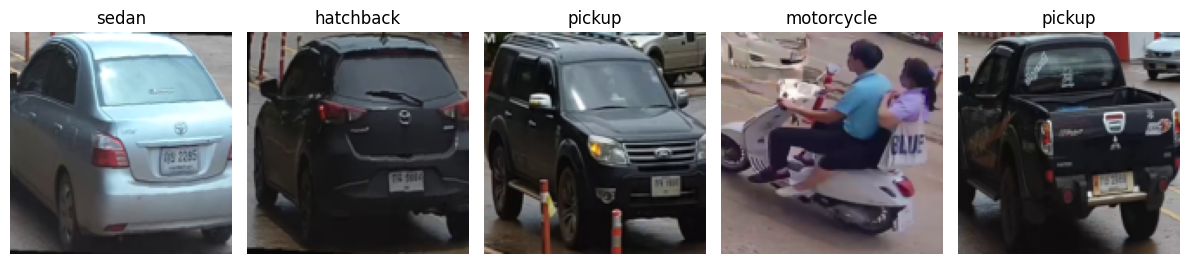

In [4]:
def show_images(X, y, label_encoder, num=5):
    plt.figure(figsize=(12, 6))
    
    for i in range(num):
        idx = np.random.randint(0, len(X))
        img = X[idx]

        # Convert from (C, H, W) → (H, W, C)
        img = np.transpose(img, (1, 2, 0))

        label = label_encoder.inverse_transform([y[idx]])[0]
        
        plt.subplot(1, num, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Display 5 images
show_images(X, y, label_encoder, num=5)


# Extract features and justify the methods used

In [5]:
def extract_hog_features(X):
    """
    X: numpy array of shape (N, C, H, W) or (N, H, W, C)
    Returns: HOG feature matrix of shape (N, num_features)
    """
    hog_features = []

    print("Extracting HOG features...")

    for i in tqdm(range(len(X))):

        img = X[i]

        # Convert from (C, H, W) -> (H, W, C) if needed
        if img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))

        # Convert image to grayscale because HOG works on single channel
        gray = rgb2gray(img)

        # Extract HOG descriptor
        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )

        hog_features.append(features)

    return np.array(hog_features)

In [6]:
X_hog = extract_hog_features(X)

print("HOG feature matrix shape:", X_hog.shape)

Extracting HOG features...


100%|██████████| 3930/3930 [00:07<00:00, 535.52it/s]

HOG feature matrix shape: (3930, 8100)


# Select features and justify the methods used.

Train shape: (3144, 8100)
Test shape: (786, 8100)
PCA reduced shape: (3144, 100)


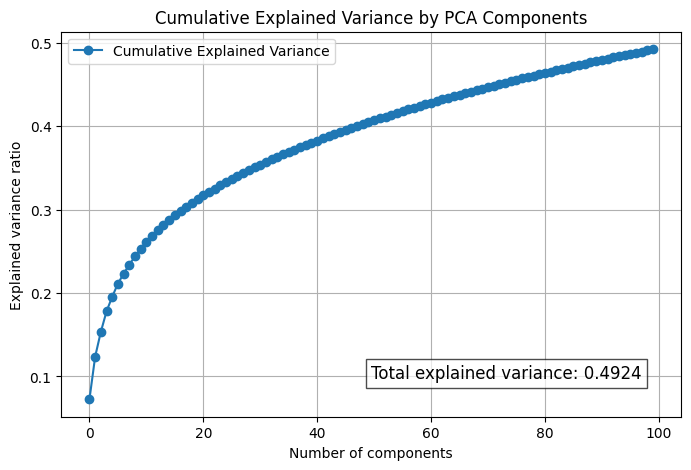

Total explained variance from PCA components: 0.492415


In [7]:
# ------------------------------------------------------------
# 1. Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ------------------------------------------------------------
# 2. Scale features BEFORE PCA
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 3. PCA: fit on training data
# ------------------------------------------------------------

pca_components = 100      # You can tune this number
pca = PCA(n_components=pca_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA reduced shape: {X_train_pca.shape}")

# ------------------------------------------------------------
# 4. Plot explained variance + show total explained variance
# ------------------------------------------------------------

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
total_explained = np.sum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(cum_var, marker='o', label="Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of components")
plt.ylabel("Explained variance ratio")
plt.grid(True)

# Display total variance on the plot
plt.text(
    0.5, 0.1,
    f"Total explained variance: {total_explained:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.legend()
plt.show()

print(f"Total explained variance from PCA components: {total_explained:.6f}")



# Implement (using the selected features) one basic machine learning algorithm for classification and justify your choice 

Training SVM on PCA features...

Accuracy (PCA + SVM): 0.9541984732824428

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       109
           1       1.00      1.00      1.00        73
           2       0.97      0.99      0.98       287
           3       0.93      0.97      0.95       240
           4       0.94      0.83      0.88        77

    accuracy                           0.95       786
   macro avg       0.96      0.93      0.94       786
weighted avg       0.95      0.95      0.95       786



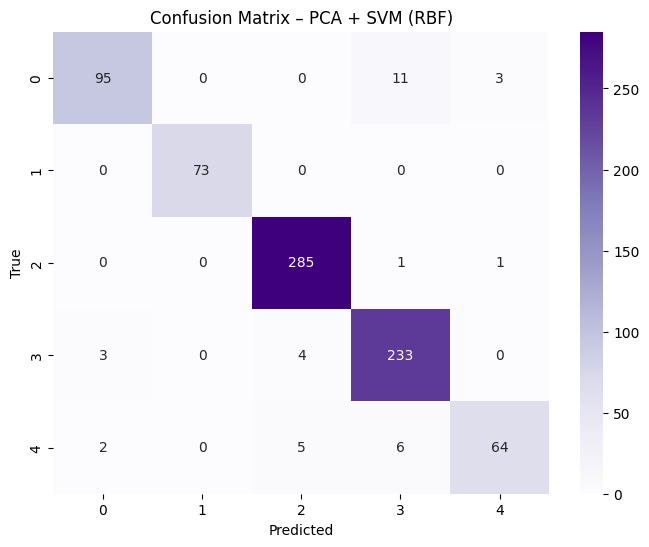

In [8]:

# ------------------------------------------------------------
# 5. Train SVM (RBF) on PCA features
# ------------------------------------------------------------

svm_pca = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

print("Training SVM on PCA features...")
svm_pca.fit(X_train_pca, y_train)

# ------------------------------------------------------------
# 6. Evaluate performance
# ------------------------------------------------------------

y_pred_pca = svm_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("\nAccuracy (PCA + SVM):", accuracy_pca)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))

# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix – PCA + SVM (RBF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
